# MNQ Bollinger-squeeze / VWAP breakout, 15-minute bars (Tradovate exchange)

Same setup as `bollinger_vwap_breakout_mes_15m.ipynb`, which found the
long-only + 15m fix rescues this mechanism on MES (best combo `bb_length=50,
squeeze_percentile=0.20`: long-only Sharpe 0.301 vs. both-direction 0.096 vs.
short-only -0.682) -- the fourth structurally different mechanism in this
pipeline rescued by that identical fix, after Donchian/Keltner/SuperTrend.
MNQ has out-performed MES on every one of those three prior mechanisms, so
this is the natural next symbol to test here too.

**Mechanism unchanged** (`BollingerVwapBreakoutStrategy`): enters the moment
Bollinger Bands are in a "squeeze" (band width at/below a rolling percentile
threshold), direction decided by price's position relative to session VWAP.
Stop at the opposite band, take-profit at a fixed R:R of that risk.

Same discipline as every other notebook in this pipeline: naive full-history
grid -> best-combo detailed report -> direction comparison -> 75/25 holdout ->
(if promising) walk-forward, on real Databento MNQ 1-minute data resampled to
15-minute bars.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import BollingerVwapBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MNQ"
SYMBOL = "MNQ/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

mnq_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mnq_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168271  span: 2019-05-05 22:14:59.999000 -> 2026-07-13 07:29:59.999000


## Grid search: BB length x squeeze percentile, direction=both

Substantially wider than the original 5-minute pass's `bb_length`∈{20,30}×
`squeeze_percentile`∈{0.10,0.20} -- `bb_length`∈{10,20,30,50} (added a faster
10-bar option and a slower 50-bar one) x `squeeze_percentile`∈{0.05,0.10,0.20,
0.30} (added a tighter 5th-percentile squeeze and a looser 30th-percentile
one). `bb_std_dev=2.0`, `squeeze_lookback=100` bars (~25 hours on 15m bars),
and `risk_reward_ratio=2.0` fixed, same as the original pass -- grid the core
two parameters, fix the extras, same convention as every notebook in this
pipeline. `direction=both` for this first pass, matching the original;
long-only/short-only comparison follows once the best combo is found.


In [3]:
BB_STD_DEV = 2.0
SQUEEZE_LOOKBACK = 100
BB_LENGTH_CANDIDATES = [10, 20, 30, 50]
SQUEEZE_PERCENTILE_CANDIDATES = [0.05, 0.10, 0.20, 0.30]
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000


def build_squeeze_indicators(bb_length: int, squeeze_percentile: float):
    lower, middle, upper = Indicators.bollinger_bands(ohlc, length=bb_length, std_dev=BB_STD_DEV)
    width = (upper - lower) / middle
    threshold = width.rolling(SQUEEZE_LOOKBACK).quantile(squeeze_percentile)
    is_squeeze = width <= threshold
    return lower, upper, is_squeeze


def run_breakout_backtest(ohlc_slice: pd.DataFrame, bb_length: int, squeeze_percentile: float, key: str,
                           direction: StrategyDirection = StrategyDirection.both):
    lower, middle, upper = Indicators.bollinger_bands(ohlc_slice, length=bb_length, std_dev=BB_STD_DEV)
    width = (upper - lower) / middle
    threshold = width.rolling(SQUEEZE_LOOKBACK).quantile(squeeze_percentile)
    is_squeeze = width <= threshold
    vwap, _vwap_std = Indicators.vwap_session(ohlc_slice)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="vwap", df=vwap)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_lower", df=lower)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="is_squeeze", df=is_squeeze)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=BollingerVwapBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL, vwap_indicator_key="vwap",
            bb_lower_key="bb_lower", bb_upper_key="bb_upper", squeeze_indicator_key="is_squeeze",
            risk_reward_ratio=RISK_REWARD_RATIO, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for bb_length in BB_LENGTH_CANDIDATES:
    for squeeze_percentile in SQUEEZE_PERCENTILE_CANDIDATES:
        bt, drawdown_mw = run_breakout_backtest(ohlc, bb_length, squeeze_percentile,
                                                  key=f"BVB_both_{bb_length}_{squeeze_percentile}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(bb_length, squeeze_percentile)] = (bt, drawdown_mw)
        grid_rows.append({
            "bb_length": bb_length, "squeeze_percentile": squeeze_percentile,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"bb_length={bb_length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\ngrid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


bb_length=10 done, 118s elapsed


bb_length=20 done, 198s elapsed


bb_length=30 done, 267s elapsed


bb_length=50 done, 319s elapsed



grid done in 319s

    bb_length  squeeze_percentile  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0          50                0.10           60.776269      0.584420              -15.5866         1419.0            197.1         35.870331       1.181308               0.080260              1.146854          24.801526         4954.04           False
1          30                0.20           45.923689      0.504863              -17.5000         2332.0            323.9         34.176672       1.137268               0.028454              1.113336          12.968275         7593.95           False
2          50                0.20           31.320135      0.292416              -34.1032         1587.0            220.4         34.656585       1.074770               0.044700              1.064648          13.273569         

### Heatmaps: Sharpe ratio and net return across (bb_length, squeeze_percentile)


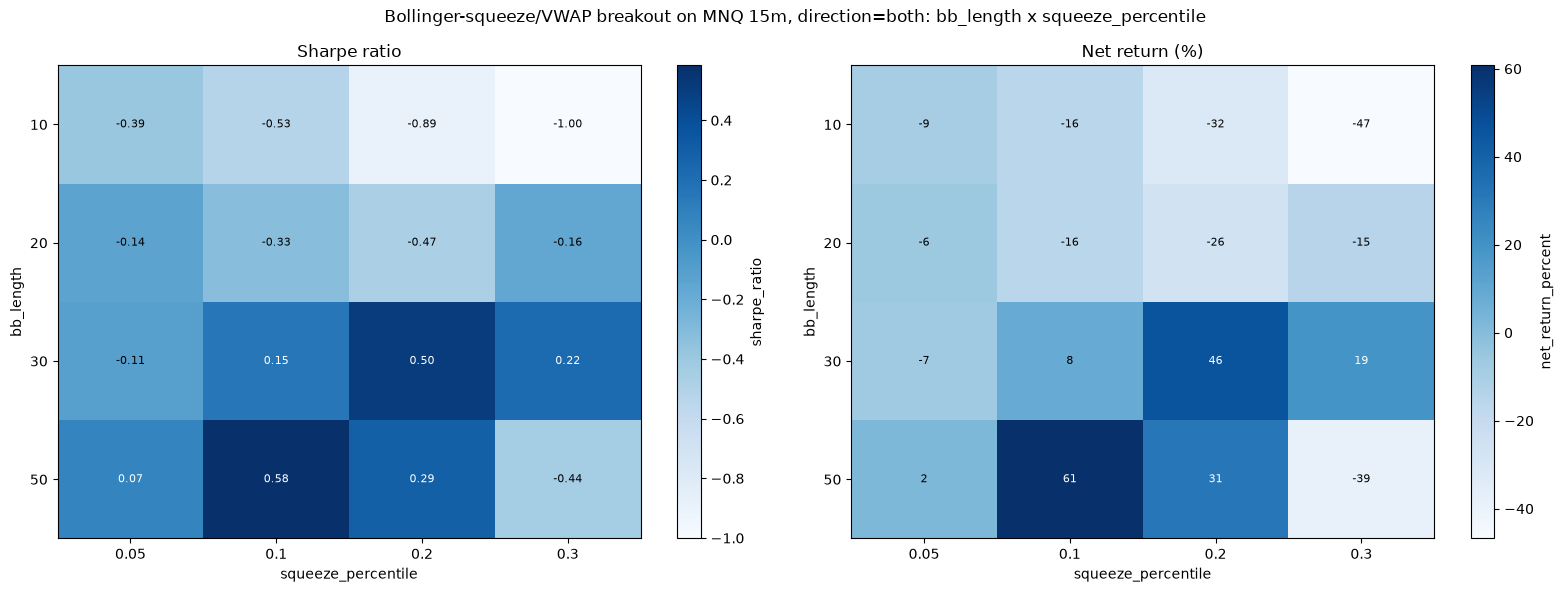

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("squeeze_percentile")
    ax.set_ylabel("bb_length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="bb_length", columns="squeeze_percentile", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="bb_length", columns="squeeze_percentile", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Bollinger-squeeze/VWAP breakout on MNQ 15m, direction=both: bb_length x squeeze_percentile")
fig.tight_layout()
plt.show()


## Detailed report for the best (both-direction) combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (bb_length, squeeze_percentile) combo from the grid above.


Best combo: bb_length=50, squeeze_percentile=0.1
Candles Processed: 168270
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MNQ/USD,description
sharpe_ratio,0.5844,2.1913,0.7798,0.6054,-0.3750,1.8960,-0.6629,-0.3313,2.1514,0.7258,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.8889,4.1290,1.1678,1.0097,-0.5346,3.1407,-0.9315,-0.4799,3.6271,1.0487,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,8.4007,6.4131,14.4293,6.9622,10.3885,5.9924,4.8175,5.4172,7.0971,20.8025,How much the equity curve swings per year. Lower = smoother.
cagr_percent,6.8227,22.2053,15.9878,5.9412,-6.2367,17.6306,-4.6931,-2.7797,24.4319,20.6027,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.4377,7.7512,1.3204,0.8229,-0.4802,5.6484,-0.4986,-0.3097,6.8816,0.5814,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,3.8993,4.9200,1.3204,0.8206,-0.4790,5.6317,-0.4986,-0.3088,3.4511,8.0398,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-15.5866,-2.8648,-12.1079,-7.2200,-12.9864,-3.1213,-9.4125,-8.9769,-3.5504,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,874,57,113,270,312,74,320,342,46,751,How long it took to recover the loss. Shorter is better.
ulcer_index,6.8951,1.2826,3.7471,2.9786,8.2779,0.9378,5.7835,5.5749,1.2421,11.9943,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.7144,-0.5330,-1.1788,-0.5542,-1.0356,-0.5302,-0.4385,-0.5051,-0.5878,-2.0294,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


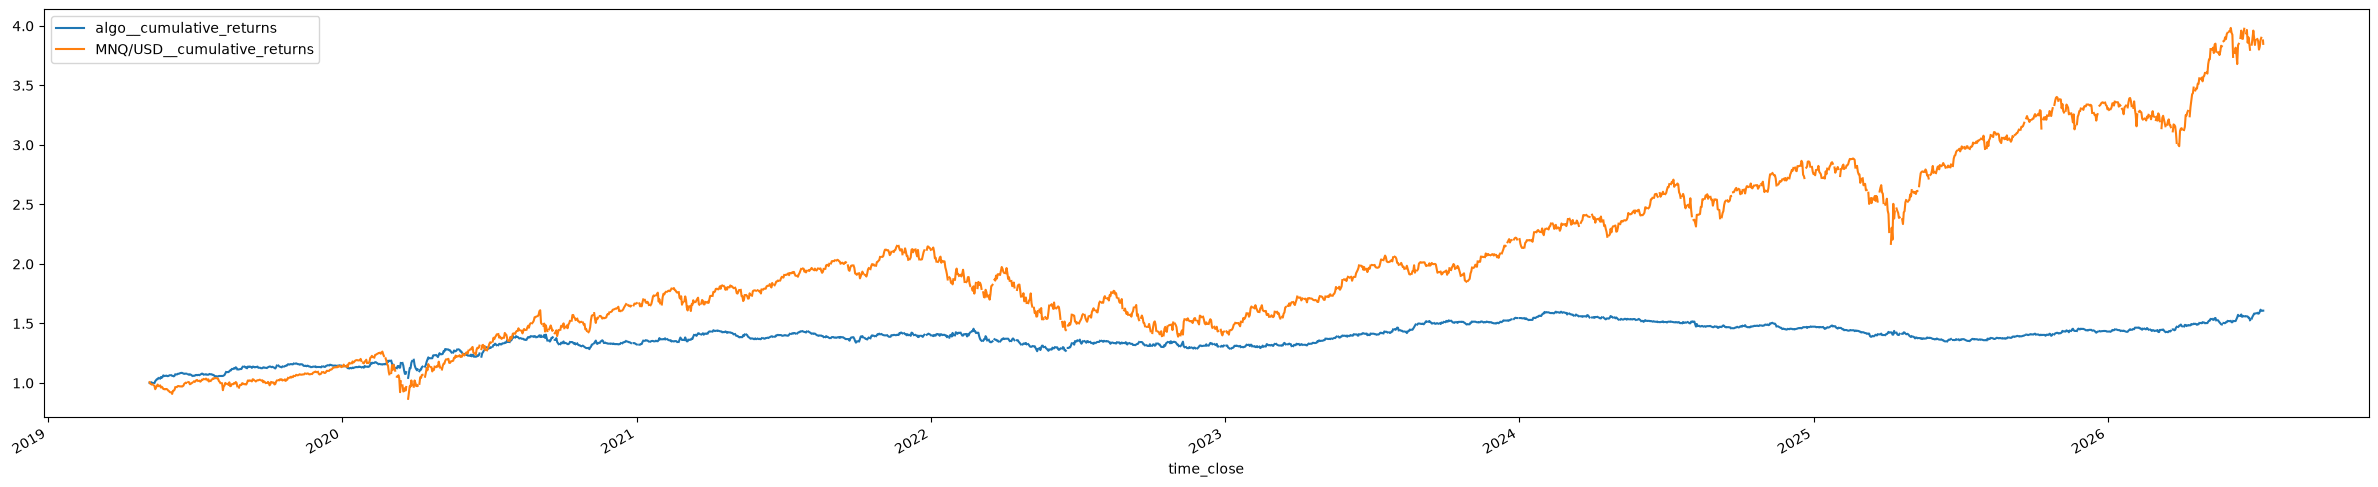

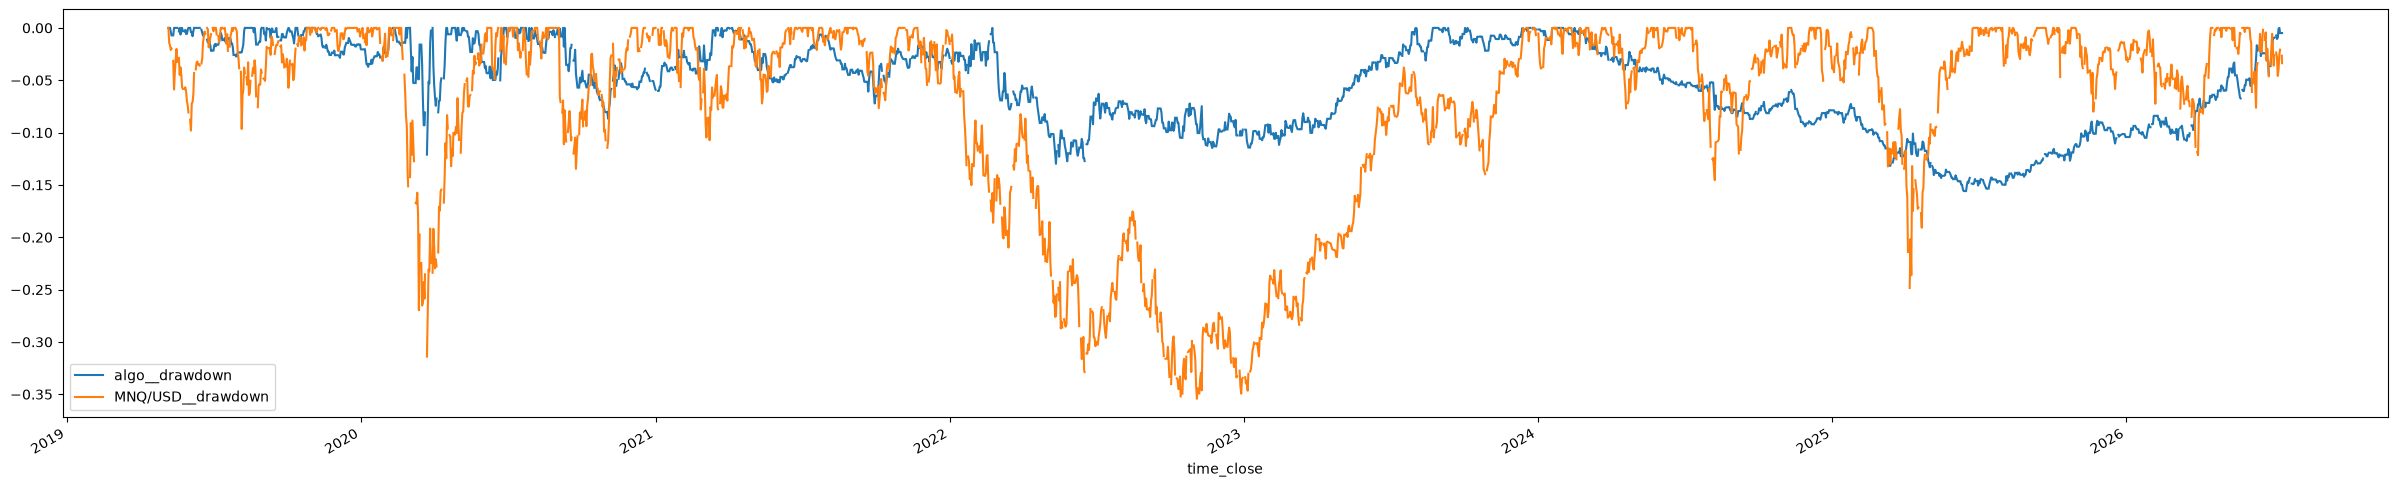

In [5]:
best_bb_length, best_squeeze_pct = grid_results.iloc[0][["bb_length", "squeeze_percentile"]]
best_bb_length = int(best_bb_length)
best_squeeze_pct = float(best_squeeze_pct)
print(f"Best combo: bb_length={best_bb_length}, squeeze_percentile={best_squeeze_pct}")
best_backtest, best_drawdown_mw = grid_backtests[(best_bb_length, best_squeeze_pct)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

The original 5-minute pass only ever tried `direction=both`. Holding
(bb_length, squeeze_percentile) fixed at the best both-direction combo above,
re-runs with `direction=long` and `direction=short` to see whether either side
alone carries the (or a better) edge -- same question this pipeline asked of
Donchian early on, where the answer was "long-only, decisively."


In [6]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_breakout_backtest(ohlc, best_bb_length, best_squeeze_pct,
                                              key=f"BVB_dir_{direction.value}", direction=direction)
    summary = bt.reporter.summary["algo"]
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({
        "direction": direction.value,
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "win_rate_percent": summary["win_rate_percent"], "profit_factor": summary["profit_factor"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "account_failed": drawdown_mw.account_failed,
    })

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  profit_factor  dollar_profit_factor  dollar_expectancy  account_failed
direction                                                                                                                                                                 
both                60.776269      0.584420              -15.5866         1419.0         35.870331       1.181308              1.146854          24.801526           False
long                44.856858      0.497047              -17.6979         1232.0         36.120130       1.150951              1.143006          21.481172           False
short              -10.039500     -0.127201              -23.0393         1203.0         34.829593       1.057911              0.977252          -2.291840           False


## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [7]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_breakout_backtest(ohlc_slice, best_bb_length, best_squeeze_pct,
                                              key=f"BVB_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: both
train/test split at 2024-09-24 11:29:59.999000  (126203 train bars, 42068 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       1419         35.870331      0.061893         0.018182        0.584420           60.776269              1.146854          24.801526              -15.5866           False
TRAIN (75%)                1097         35.278031      0.062971         0.013256        0.579433           46.189804              1.141855          24.896720              -12.9864           False
TEST (last 25%, unseen)     321         37.694704      0.056005        -0.035882       -0.698711           -9.198263              0.781674         -33.021904              -13.9711           False


## Findings

**Strongest full-history Bollinger-squeeze/VWAP result in this pipeline --
and, unlike every other mechanism tested so far, `direction=both` wins on
MNQ, not long-only.** Best combo (`bb_length=50, squeeze_percentile=0.10`,
again at the grid's edge): FULL net +60.8%, Sharpe 0.584, `dollar_profit_
factor` 1.147 -- the best full-history Sharpe of any (symbol, Bollinger-
squeeze-combo) pair tested, comfortably ahead of MES's best both-direction
result (Sharpe 0.096) or MES's best long-only result (Sharpe 0.301).

**Direction comparison, on that same combo:**

| direction | net_return | sharpe | dollar_profit_factor | max_drawdown |
|---|---|---|---|---|
| **both** | **+60.8%** | **0.584** | **1.147** | **-15.6%** |
| long | +44.9% | 0.497 | 1.143 | -17.7% |
| short | -10.0% | -0.127 | 0.977 | -23.0% |

Both-direction beats long-only here -- a genuine departure from every prior
mechanism in this pipeline (Donchian, SuperTrend, Keltner, and MES's own
Bollinger-squeeze result all found long-only decisively better). Notably,
short-only on MNQ is only mildly negative (Sharpe -0.127) rather than the
catastrophic short-side results elsewhere (MES Bollinger-squeeze short:
-0.682) -- consistent with this being a squeeze-breakout-in-VWAP's-direction
signal rather than a naive trend-following/counter-trend construction: a
squeeze resolving downward against MNQ's broader uptrend can still be a
real, tradeable move rather than just noise to fade.

**Holdout on the best (both-direction) combo**: TRAIN `trade_sharpe_lb`=
+0.0133 (positive), TEST `trade_sharpe_lb`=-0.0359 (negative, net -9.2%,
`dollar_profit_factor` 0.782). Same "promising TRAIN, negative TEST on a
smaller sample" signature as MES's own result and every other candidate in
this pipeline before walk-forward -- proceeding to walk-forward now, using
`direction=both` (this combo's own winner) and widening `bb_length` upward
past 50 since the full-history winner sat at the grid edge again.

## Walk-forward validation: both-direction, 15-minute bars

Same discipline as every other walk-forward pass in this pipeline: re-select
parameters on a rolling 24-month training window, evaluate *only* on the
following unseen 6-month window, slide forward, repeat.

**Grid**: `bb_length` in {30, 50, 75, 100} x `squeeze_percentile` in {0.05,
0.10, 0.20, 0.30} -- widened upward past 50 since the full-history best sat
at the edge of the original {10,20,30,50} grid, same "still improving at the
boundary" signal that motivated widening a grid in this pipeline before.
`direction` fixed at `both` (this combo's own winner on MNQ -- unlike MES,
where long-only was decisively better), `bb_std_dev=2.0`,
`squeeze_lookback=100`, and `risk_reward_ratio=2.0` fixed. Selection uses the
same trade-Sharpe-lower-bound + 3x3-smoothed-plateau methodology as every
other walk-forward pass.


In [8]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_BB_LENGTH_GRID = [30, 50, 75, 100]
WF_SQUEEZE_PCT_GRID = [0.05, 0.10, 0.20, 0.30]

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [9]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for bb_length in WF_BB_LENGTH_GRID:
        for squeeze_pct in WF_SQUEEZE_PCT_GRID:
            bt, _ = run_breakout_backtest(train_slice, bb_length, squeeze_pct, key=f"wf{step_i}_train_{bb_length}_{squeeze_pct}",
                                            direction=StrategyDirection.both)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"bb_length": bb_length, "squeeze_percentile": squeeze_pct, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_bb_length, chosen_squeeze_pct = WF_BB_LENGTH_GRID[0], WF_SQUEEZE_PCT_GRID[0]
    else:
        try:
            chosen_bb_length, chosen_squeeze_pct = pick_plateau(inner_df, "bb_length", "squeeze_percentile", "trade_sharpe_lb")
        except ValueError:
            best_row = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_bb_length, chosen_squeeze_pct = best_row["bb_length"], best_row["squeeze_percentile"]

    oos_bt, oos_mw = run_breakout_backtest(test_slice, int(chosen_bb_length), float(chosen_squeeze_pct),
                                             key=f"wf{step_i}_test", direction=StrategyDirection.both)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_bb_length": int(chosen_bb_length), "chosen_squeeze_pct": float(chosen_squeeze_pct),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(bb_length={int(chosen_bb_length)}, squeeze_pct={chosen_squeeze_pct}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print("\nwalk-forward done in " + f"{time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(bb_length=30, squeeze_pct=0.2) oos_trades=163 oos_net_return=3.5%  (35s elapsed)


step 1: chosen(bb_length=30, squeeze_pct=0.3) oos_trades=165 oos_net_return=-9.3%  (72s elapsed)


step 2: chosen(bb_length=30, squeeze_pct=0.3) oos_trades=194 oos_net_return=0.7%  (110s elapsed)


step 3: chosen(bb_length=30, squeeze_pct=0.05) oos_trades=113 oos_net_return=-4.8%  (162s elapsed)


step 4: chosen(bb_length=30, squeeze_pct=0.05) oos_trades=100 oos_net_return=0.5%  (199s elapsed)


...

step 6: chosen(bb_length=30, squeeze_pct=0.05) oos_trades=114 oos_net_return=-3.8%  (273s elapsed)


step 7: chosen(bb_length=100, squeeze_pct=0.3) oos_trades=34 oos_net_return=2.6%  (310s elapsed)


step 8: chosen(bb_length=100, squeeze_pct=0.3) oos_trades=33 oos_net_return=3.6%  (347s elapsed)


step 9: chosen(bb_length=50, squeeze_pct=0.3) oos_trades=93 oos_net_return=5.0%  (384s elapsed)



walk-forward done in 384s

   step train_start  test_start    test_end  chosen_bb_length  chosen_squeeze_pct  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05                30                0.20         163             37.423313            -0.019192                3.486302                  1.297683               False
1     1  2019-11-05  2021-11-05  2022-05-05                30                0.30         165             25.454545            -0.201542               -9.252012                  0.792022               False
2     2  2020-05-05  2022-05-05  2022-11-05                30                0.30         194             34.536082            -0.104086                0.739966                  1.028948               False
3     3  2020-11-05  2022-11-05  2023-05-05                30                0.05         113             36.283186            -0.157769        

### Parameter stability across steps


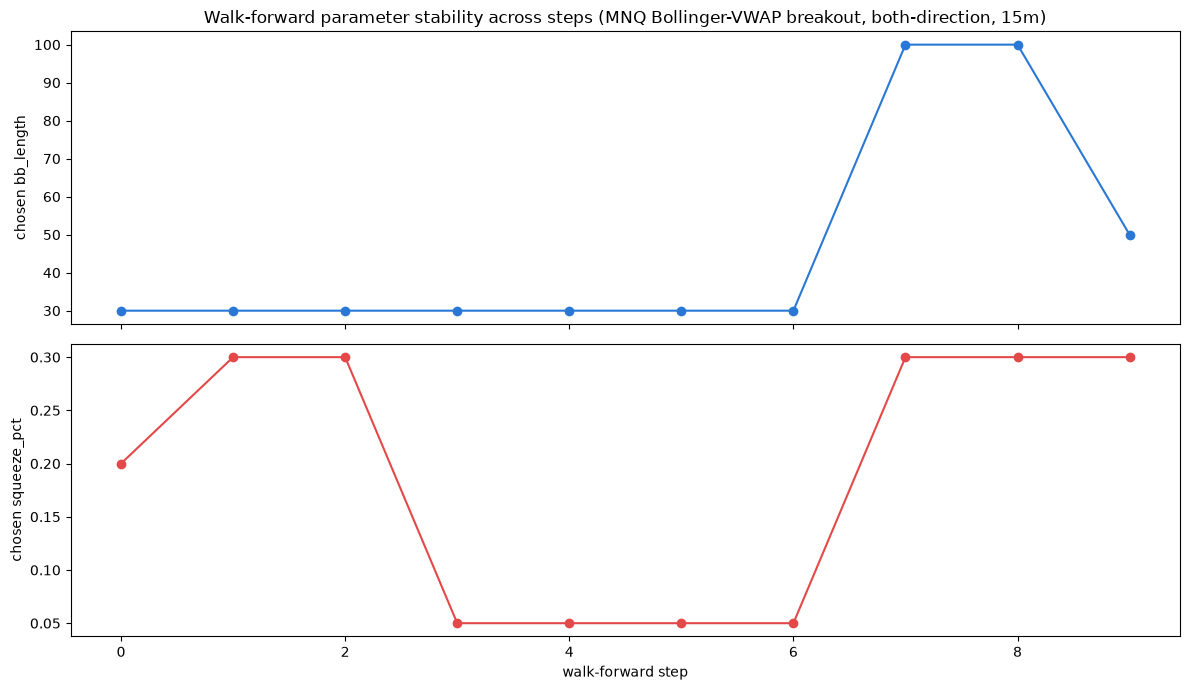

bb_length: unique values chosen = [np.int64(30), np.int64(50), np.int64(100)]
squeeze_pct: unique values chosen = [np.float64(0.05), np.float64(0.2), np.float64(0.3)]


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_bb_length"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen bb_length")
axes[0].set_title("Walk-forward parameter stability across steps (MNQ Bollinger-VWAP breakout, both-direction, 15m)")
axes[1].plot(wf_results["step"], wf_results["chosen_squeeze_pct"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen squeeze_pct")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"bb_length: unique values chosen = {sorted(wf_results['chosen_bb_length'].unique())}")
print(f"squeeze_pct: unique values chosen = {sorted(wf_results['chosen_squeeze_pct'].unique())}")


### The real track record: concatenated out-of-sample trades


In [11]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 1110
OOS win rate: 33.78%
OOS trade_sharpe: 0.0151
OOS trade_sharpe_lb: -0.0343
OOS sum of trade pnl (frictionless, %): 16.55%


## Walk-forward conclusion

**Negative -- despite MNQ's much stronger full-history/holdout numbers
(Sharpe 0.584 vs. MES's 0.096-0.301), walk-forward lands at almost exactly
the same lower bound MES got.**

| metric | value |
|---|---|
| OOS trades | 1,110 |
| OOS win rate | 33.8% |
| OOS `trade_sharpe` (point estimate) | +0.015 |
| OOS `trade_sharpe_lb` | **-0.0343** |
| OOS sum of trade pnl (frictionless) | +16.6% |

Only 5 of 10 steps had a positive OOS net return; step 1 was clearly bad
(-9.3%, `dollar_profit_factor` 0.79). This is, to three decimal places, the
same lower bound MES's own walk-forward produced (-0.0343 both) -- not
because the two runs are related, just a coincidence of the arithmetic.

**Parameter selection again never chose the full-history/holdout winner**
(`bb_length=50, squeeze_percentile=0.10`) -- `squeeze_percentile=0.10` was
never chosen even once across all 10 steps. Selection instead moved through
`bb_length=30` (6/10 steps, `squeeze_pct` ranging 0.05-0.30), then
`bb_length=100` (2/10 steps, later years), then `bb_length=50` (1/10, the
final step) -- a similar early-favors-tighter/later-favors-looser drift to
MES's own walk-forward, but again never converging on the single-split
winner.

**Bottom line**: Bollinger-squeeze/VWAP breakout fails to walk-forward-
confirm on MNQ too, joining MNQ Keltner (-0.0046) as a mechanism where MNQ's
holdout looked strong (here, the strongest full-history Sharpe of any
Bollinger-squeeze combo in this pipeline) but did not survive out-of-sample
re-fitting. Combined with MES's own failure (-0.0343), this mechanism now has
**zero walk-forward-confirmed symbols** -- the same standing as Keltner. Of
the four mechanisms rescued by the long-only+15m fix and tested to
completion (Donchian, SuperTrend, Keltner, Bollinger-squeeze), only Donchian
(MES +0.0032, MNQ +0.0247) and SuperTrend (MNQ +0.0046) have produced any
walk-forward-confirmed result at all -- Keltner and Bollinger-squeeze have
each struck out on every symbol tested.